[2026-06-25 16:45:26] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-06-25 16:45:26] [info     ] 开始构造尾盘拥挤残差反转因子                 end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-06-25 16:45:26] [info     ] build_factor 开始                end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-06-25 16:46:21] [info     ] 分钟数据聚合完成                       elapsed=54.7 rows=657209
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On ent

时段,IC
2024-01-15~2024-02-08,0.0054
2024-09-24~2024-10-08,0.0534

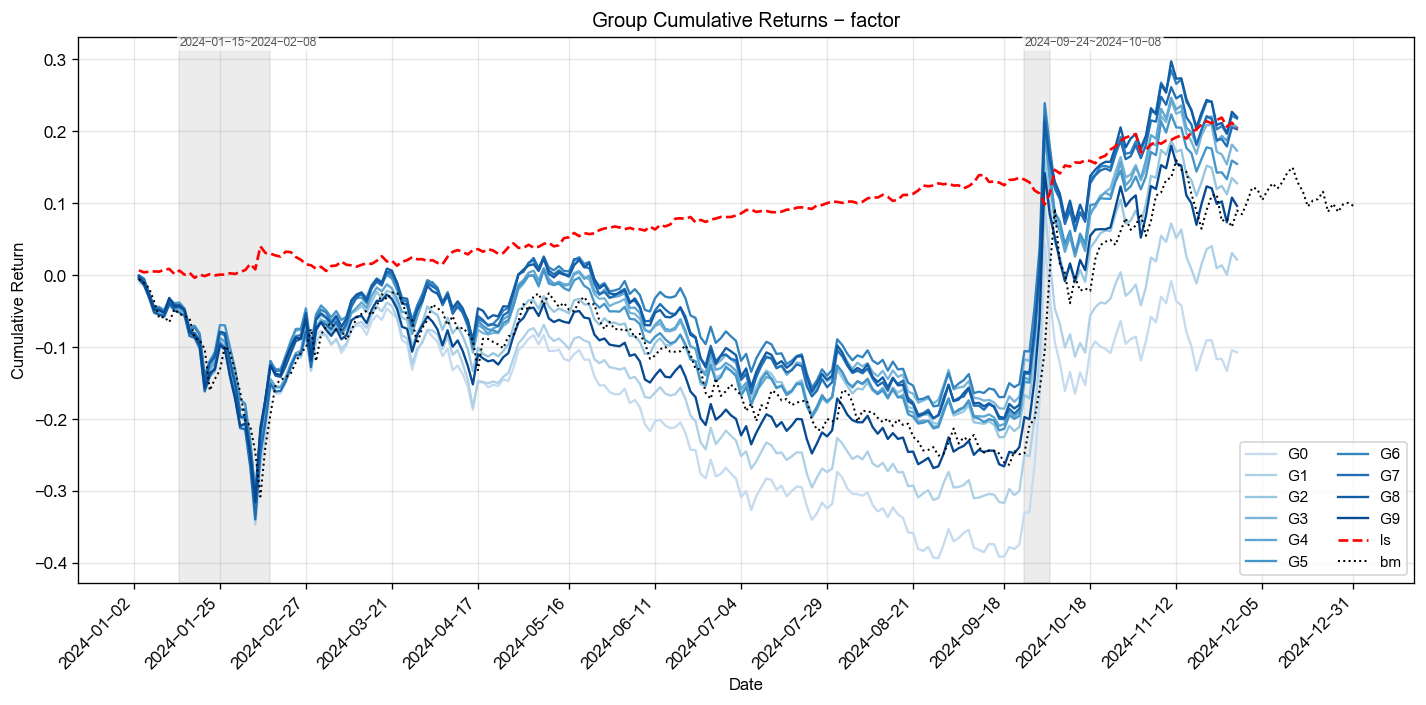
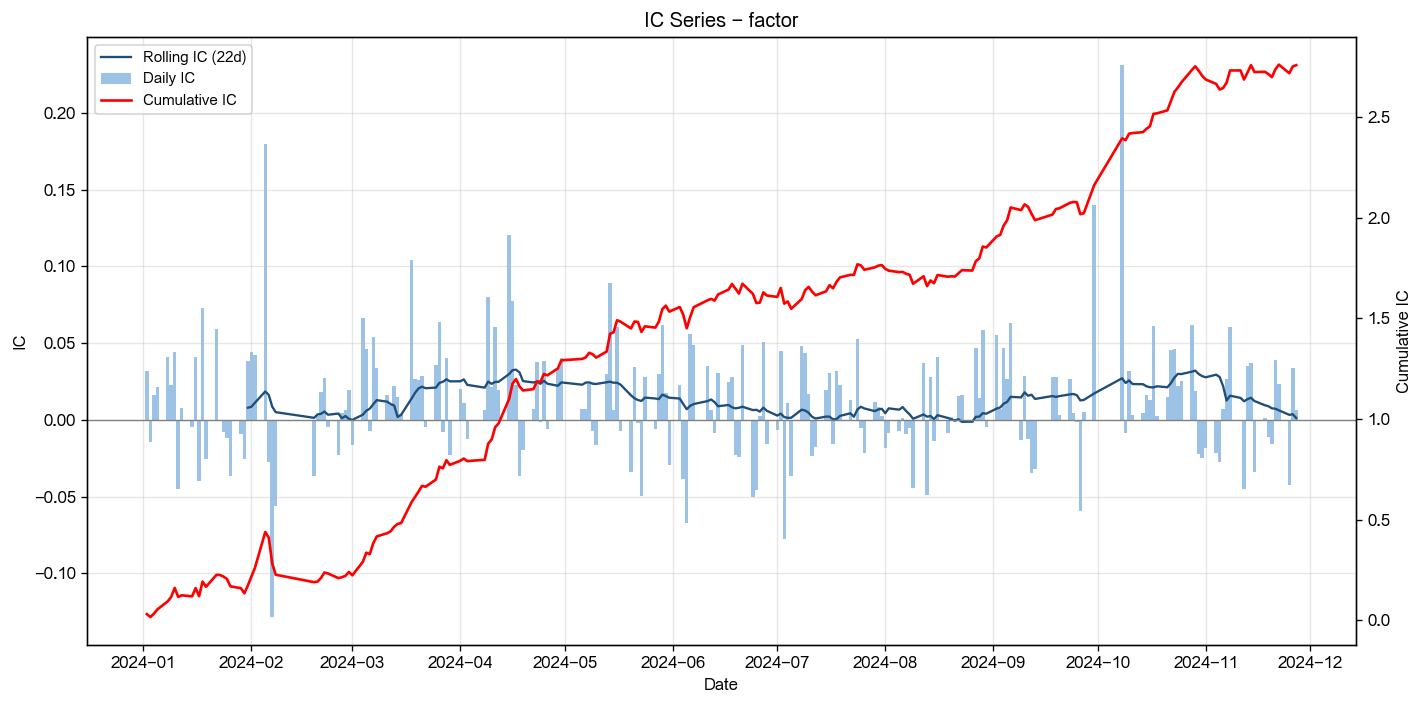
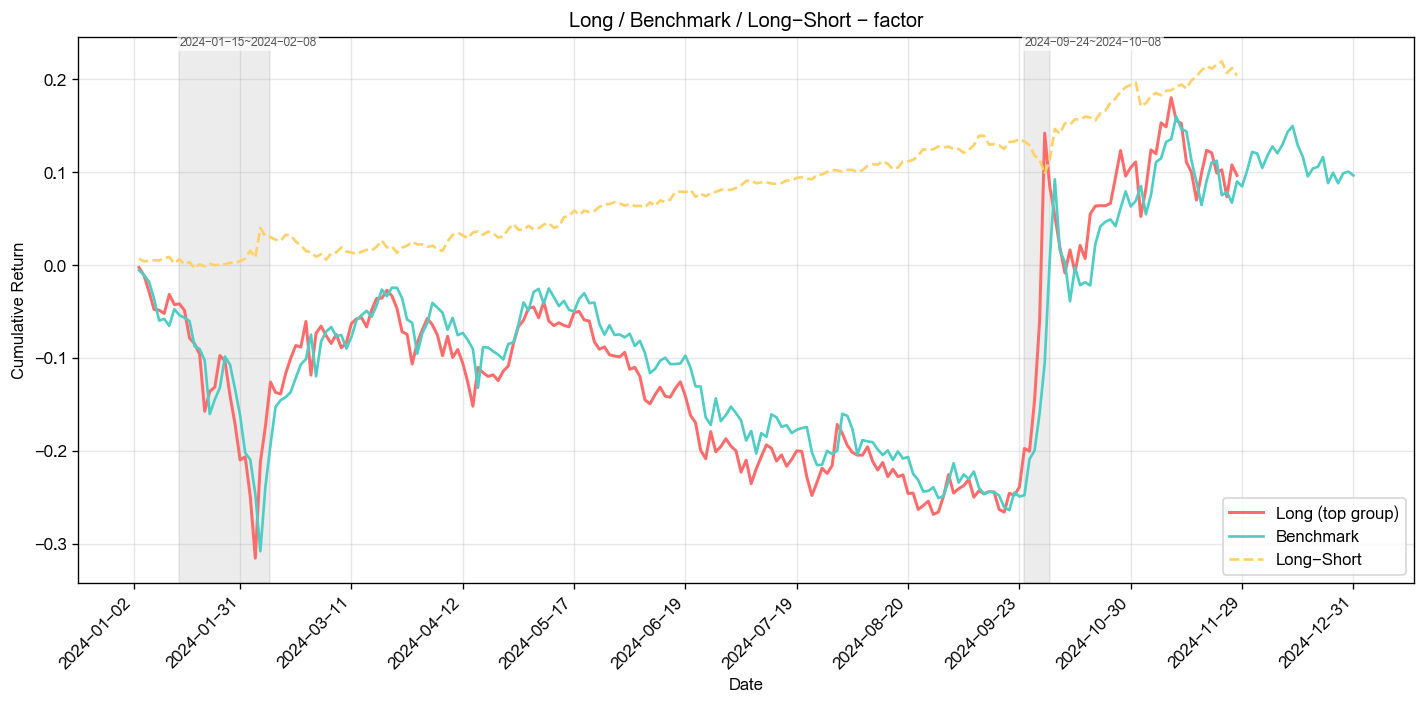
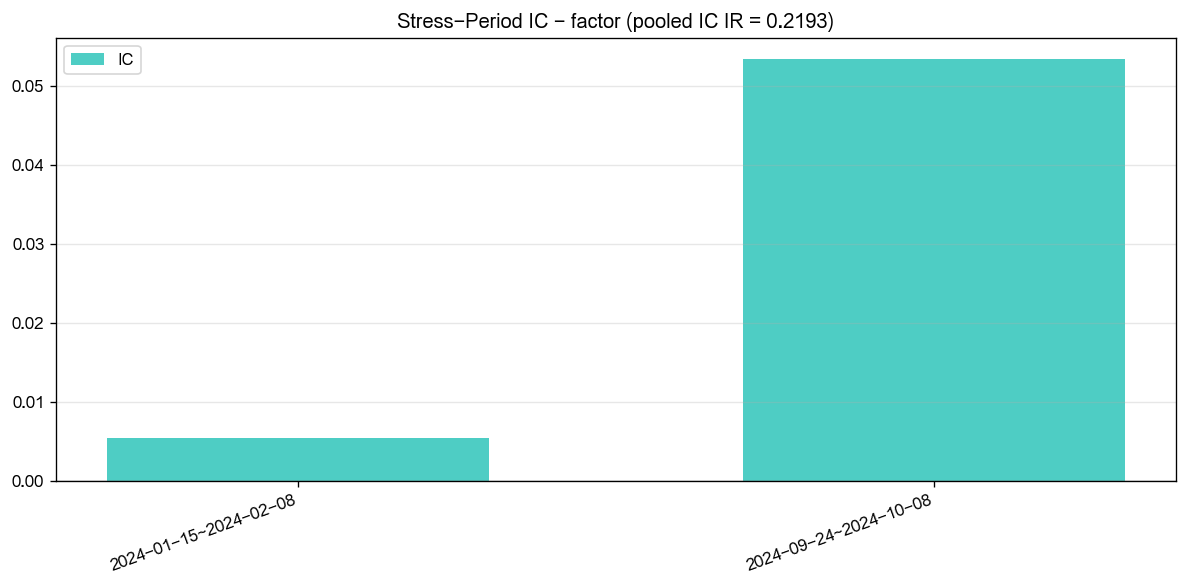
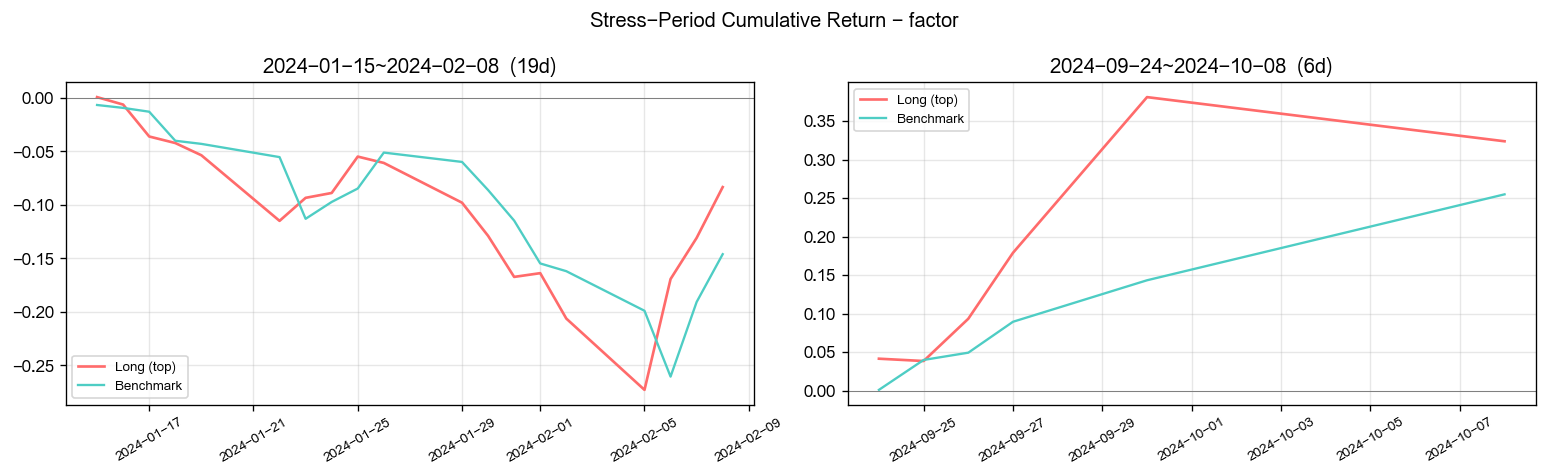

[2026-06-25 16:53:55] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-06-25 16:53:56] [warning  ] 返回的Outputs实例(size=35297383) 大于 64K, 将不会被缓存
[2026-06-25 16:53:56] [info     ] bigalpha_eval.v1 运行完成 [399.287s].


In [1]:
def main(datasources, start_date, end_date):
    """
    单因子：尾盘拥挤残差反转因子

    使用 t 日全部收盘后可得信息预测 t+1 日收益。

    核心逻辑：
        1. 从 1 分钟 bar 聚合日频 OHLCV；
        2. 额外提取尾盘 14:30-15:00 的价格变化和成交额占比；
        3. 构造尾盘拥挤反转信号；
        4. 每日横截面残差化，去除普通日频反转/振幅/成交额/波动率暴露；
        5. 每日 rank 后输出单因子。
    """
    import time
    import numpy as np
    import pandas as pd
    import dai
    import structlog

    logger = structlog.get_logger()
    EPS = 1e-12

    # ============================================================
    # 横截面工具函数
    # ============================================================
    def cs_winsorize(s, q=0.01):
        s = s.replace([np.inf, -np.inf], np.nan)
        if s.notna().sum() < 20:
            return s
        lo = s.quantile(q)
        hi = s.quantile(1 - q)
        return s.clip(lo, hi)

    def cs_zscore(s):
        s = s.replace([np.inf, -np.inf], np.nan)
        mu = s.mean()
        sd = s.std()
        return (s - mu) / (sd + EPS)

    def cs_rank(s):
        s = s.replace([np.inf, -np.inf], np.nan)
        return s.rank(pct=True) - 0.5

    def residualize_by_date(df, y_col, x_cols, out_col):
        """
        每日横截面 OLS 残差化：
            y = alpha + X beta + resid

        用于去掉普通日频风格暴露，提高相对基础因子库的增量信息。
        """
        out_list = []

        use_cols = ['date', 'instrument', y_col] + x_cols
        tmp_df = df[use_cols].replace([np.inf, -np.inf], np.nan)

        for dt, sub in tmp_df.groupby('date'):
            sub = sub.dropna(subset=[y_col])

            if len(sub) < len(x_cols) + 30:
                tmp = sub[['date', 'instrument']].copy()
                tmp[out_col] = np.nan
                out_list.append(tmp)
                continue

            # X 缺失用当日中位数填充
            X_df = sub[x_cols].copy()
            for c in x_cols:
                med = X_df[c].median()
                X_df[c] = X_df[c].fillna(med)

            y = sub[y_col].values.astype(float)
            X = X_df.values.astype(float)

            # 加截距
            X = np.column_stack([np.ones(len(X)), X])

            try:
                beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
                resid = y - X @ beta
            except Exception:
                resid = y - np.nanmean(y)

            tmp = sub[['date', 'instrument']].copy()
            tmp[out_col] = resid
            out_list.append(tmp)

        if len(out_list) == 0:
            df[out_col] = np.nan
            return df

        resid_df = pd.concat(out_list, axis=0)
        df = df.merge(resid_df, on=['date', 'instrument'], how='left')
        return df

    # ============================================================
    # 构造因子
    # ============================================================
    def build_factor(bar1m_table, sd, ed):
        t0 = time.time()
        logger.info("build_factor 开始", start=str(sd), end=str(ed))

        # 多取历史，用于计算 20 日波动率
        price_start = pd.to_datetime(sd) - pd.Timedelta(days=90)

        # ========================================================
        # 从 1 分钟表中同时提取：
        #   日频 OHLCV；
        #   尾盘 14:30 后的成交额；
        #   14:30 后第一根 close；
        #   当日最后 close。
        # ========================================================
        price_sql = f"""
        WITH minute AS (
            SELECT
                date,
                date_trunc('day', date)::DATE AS trading_day,
                instrument,
                open,
                high,
                low,
                close,
                volume,
                amount
            FROM {bar1m_table}
        ),
        daily AS (
            SELECT
                trading_day,
                instrument,
                ARG_MIN(open, date) AS open,
                MAX(high) AS high,
                MIN(low) AS low,
                ARG_MAX(close, date) AS close,
                SUM(volume) AS volume,
                SUM(amount) AS amount
            FROM minute
            GROUP BY trading_day, instrument
        ),
        tail AS (
            SELECT
                trading_day,
                instrument,
                ARG_MIN(close, date) AS close_1430,
                ARG_MAX(close, date) AS close_tail,
                SUM(volume) AS volume_tail,
                SUM(amount) AS amount_tail
            FROM minute
            WHERE CAST(date AS TIME) >= TIME '14:30:00'
            GROUP BY trading_day, instrument
        )
        SELECT
            d.trading_day,
            d.instrument,
            d.open,
            d.high,
            d.low,
            d.close,
            d.volume,
            d.amount,
            t.close_1430,
            t.close_tail,
            t.volume_tail,
            t.amount_tail
        FROM daily d
        LEFT JOIN tail t
        ON d.trading_day = t.trading_day
        AND d.instrument = t.instrument
        ORDER BY d.trading_day, d.instrument
        """

        price = (
            dai.query(price_sql, filters={'date': [price_start, ed]})
               .df()
               .rename(columns={'trading_day': 'date'})
        )

        price['date'] = pd.to_datetime(price['date'])
        price['instrument'] = price['instrument'].astype(str)

        num_cols = [
            'open', 'high', 'low', 'close', 'volume', 'amount',
            'close_1430', 'close_tail', 'volume_tail', 'amount_tail'
        ]

        for col in num_cols:
            price[col] = pd.to_numeric(price[col], errors='coerce')
            price[col] = price[col].replace([np.inf, -np.inf], np.nan)

        price = price.sort_values(['instrument', 'date']).reset_index(drop=True)

        logger.info(
            "分钟数据聚合完成",
            rows=len(price),
            elapsed=round(time.time() - t0, 2)
        )

        # ========================================================
        # 基础变量
        # ========================================================
        g = price.groupby('instrument', group_keys=False)

        # 日收益：普通基础反转暴露，后面会被残差化去掉
        price['ret1'] = g['close'].pct_change()

        # 日内振幅
        price['range'] = (price['high'] - price['low']) / (price['close'] + EPS)

        # 成交额规模
        price['log_amount'] = np.log1p(price['amount'])

        # 20 日波动率
        price['vol20'] = (
            g['ret1']
            .rolling(20, min_periods=10)
            .std()
            .reset_index(level=0, drop=True)
        )

        # 尾盘收益：14:30 到收盘
        price['tail_ret'] = price['close_tail'] / (price['close_1430'] + EPS) - 1

        # 尾盘成交额占比
        price['tail_amount_share'] = price['amount_tail'] / (price['amount'] + EPS)

        # ========================================================
        # 尾盘拥挤强度：每日横截面 z-score，只取正向拥挤
        # ========================================================
        price['tail_share_z'] = (
            price.groupby('date')['tail_amount_share']
                 .transform(lambda s: cs_zscore(cs_winsorize(s, q=0.01)))
        )

        price['tail_crowding'] = price['tail_share_z'].clip(lower=0)

        # ========================================================
        # 原始尾盘拥挤反转信号
        #
        # 如果尾盘强拉 + 尾盘成交拥挤，则 raw_factor 更负；
        # 如果尾盘强砸 + 尾盘成交拥挤，则 raw_factor 更正。
        # ========================================================
        price['raw_factor'] = (
            -price['tail_ret']
            * (1.0 + price['tail_crowding'])
        )

        # 先对 raw_factor 做每日去极值
        price['raw_factor'] = (
            price.groupby('date')['raw_factor']
                 .transform(lambda s: cs_winsorize(s, q=0.01))
        )

        # ========================================================
        # 对普通基础因子做残差化
        #
        # 这样提交的不是普通反转、波动率、成交额、振幅，
        # 而是这些日频基础因子解释不了的“尾盘结构信息”。
        # ========================================================
        base_cols = ['ret1', 'range', 'log_amount', 'vol20']

        # base cols 每日横截面标准化，避免量纲影响 OLS
        for c in base_cols:
            price[f'z_{c}'] = (
                price.groupby('date')[c]
                     .transform(lambda s: cs_zscore(cs_winsorize(s, q=0.01)))
            )

        z_base_cols = [f'z_{c}' for c in base_cols]

        price = residualize_by_date(
            price,
            y_col='raw_factor',
            x_cols=z_base_cols,
            out_col='raw_factor_resid'
        )

        # ========================================================
        # 最终因子：残差每日 rank
        # ========================================================
        price['factor'] = (
            price.groupby('date')['raw_factor_resid']
                 .transform(lambda s: cs_rank(cs_winsorize(s, q=0.01)))
        )

        # 只输出目标区间
        price = price[
            (price['date'] >= pd.to_datetime(sd)) &
            (price['date'] <= pd.to_datetime(ed))
        ]

        price['factor'] = price['factor'].replace([np.inf, -np.inf], np.nan)
        price['factor'] = price['factor'].fillna(0.0)

        logger.info(
            "build_factor 结束",
            rows=len(price),
            total_elapsed=round(time.time() - t0, 2)
        )

        return price[['date', 'instrument', 'factor']].reset_index(drop=True)

    # ============================================================
    # 第 1 步：构造单因子
    # ============================================================
    bar1m_table = datasources['bar1m']

    logger.info("开始构造尾盘拥挤残差反转因子", start=start_date, end=end_date)
    factor_df = build_factor(bar1m_table, start_date, end_date)

    # ============================================================
    # 第 2 步：对齐中证 1000 成分股
    # ============================================================
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()

    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)

    result = pd.merge(
        factor_df,
        stk_pool,
        how='inner',
        on=['date', 'instrument']
    )

    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)

    result = (
        result.dropna(subset=['factor'])
              .reset_index(drop=True)[['date', 'instrument', 'factor']]
    )

    logger.info("因子构建完成", rows=len(result))
    return result


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial'
    }

    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        show=True,
    )